In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from pymatgen.core import Structure
from matminer.featurizers.base import MultipleFeaturizer
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty
from matminer.featurizers.structure import (SiteStatsFingerprint, StructuralHeterogeneity,
                                            ChemicalOrdering, StructureComposition, MaximumPackingEfficiency)
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset    
* The Materials Project database can be obtained based on API
* Read the dataset after preliminary high-throughput screening

In [2]:
df = pd.read_json('./data/MP_dataset_screened.json')
df

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,band_gap,is_metal,bulk_modulus,shear_modulus,structure_json
0,6,3,LiBeSb,ABC,102.232248,4.473698,mp-9575,-3.567269,-0.308157,0.017807,0.8731,False,56.099,47.692,"{'@module': 'pymatgen.core.structure', '@class..."
1,4,2,K3Sb,AB3,151.112621,2.626915,mp-10159,-11.473373,-0.533096,0.015186,0.6773,False,13.114,6.582,"{'@module': 'pymatgen.core.structure', '@class..."
2,8,3,Na2CuP,ABC2,154.577587,3.018608,mp-7639,-7.208147,-0.463838,0.000000,0.6575,False,34.554,20.740,"{'@module': 'pymatgen.core.structure', '@class..."
3,14,3,Ba3OsN3,AB3C3,332.309469,6.438402,mp-1029640,-6.639529,-0.639654,0.000000,0.6770,False,48.894,26.010,"{'@module': 'pymatgen.core.structure', '@class..."
4,6,2,As2Os,AB2,102.413553,11.027932,mp-2455,-27.770656,-0.303893,0.000000,0.6647,False,166.406,119.207,"{'@module': 'pymatgen.core.structure', '@class..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2670,4,3,ZnGeP2,ABC2,81.630946,4.068335,mp-1215424,-10.443534,-0.246851,0.028254,0.1435,False,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."
2671,15,3,Li4Mo3O8,A3B4C8,171.512523,4.294617,mp-566257,-7.394573,-2.075190,0.049916,1.5855,False,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."
2672,4,3,TePb2Se,ABC2,128.302463,8.036699,mp-1217291,-38.654399,-0.579636,0.008565,0.6214,False,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."
2673,4,3,KBiS2,ABC2,108.994826,4.756508,mp-1223443,-4.361594,-1.049450,0.000000,1.4158,False,NaN,NaN,"{'@module': 'pymatgen.core.structure', '@class..."


# 2. Feature engineering  
* Composition-based features are generated based on Magpie data
* Structure-based features can be derived from Voronoi tessellations

In [3]:
df['structure'] = df['structure_json'].apply(lambda x: Structure.from_dict(x, fmt='json'))

In [4]:
df.columns

Index(['nsites', 'nelements', 'formula_pretty', 'formula_anonymous', 'volume',
       'density', 'material_id', 'energy_per_atom',
       'formation_energy_per_atom', 'energy_above_hull', 'band_gap',
       'is_metal', 'bulk_modulus', 'shear_modulus', 'structure_json',
       'structure'],
      dtype='object')

## 2.1 Feature generation
### Featrurization process may take a few minutes

In [5]:
featurizer = MultipleFeaturizer([
    SiteStatsFingerprint.from_preset("CoordinationNumber_ward-prb-2017"),
    StructuralHeterogeneity(),
    ChemicalOrdering(),  
    
    MaximumPackingEfficiency(),
    SiteStatsFingerprint.from_preset("LocalPropertyDifference_ward-prb-2017"),
    StructureComposition(Stoichiometry()),
    StructureComposition(ElementProperty.from_preset("magpie")),
    StructureComposition(ValenceOrbital(props=['frac'])),
    StructureComposition(IonProperty(fast=True))
])

df_fea = featurizer.featurize_dataframe(df, col_id="structure")
df_fea.head()

MultipleFeaturizer:   0%|          | 0/2675 [00:00<?, ?it/s]

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,...,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,compound possible,max ionic char,avg ionic char
0,6,3,LiBeSb,ABC,102.232248,4.473698,mp-9575,-3.567269,-0.308157,0.017807,...,196.333333,21.777778,166.0,0.277778,0.166667,0.555556,0.000000,True,0.248906,0.043136
1,4,2,K3Sb,AB3,151.112621,2.626915,mp-10159,-11.473373,-0.533096,0.015186,...,213.250000,23.625000,229.0,0.277778,0.166667,0.555556,0.000000,True,0.314924,0.059048
2,8,3,Na2CuP,ABC2,154.577587,3.018608,mp-7639,-7.208147,-0.463838,0.000000,...,171.250000,84.625000,229.0,0.277778,0.166667,0.555556,0.000000,False,0.327599,0.068451
3,14,3,Ba3OsN3,AB3C3,332.309469,6.438402,mp-1029640,-6.639529,-0.639654,0.000000,...,209.000000,17.142857,194.0,0.325581,0.209302,0.139535,0.325581,False,0.685139,0.157102
4,6,2,As2Os,AB2,102.413553,11.027932,mp-2455,-27.770656,-0.303893,0.000000,...,175.333333,12.444444,166.0,0.115385,0.115385,0.500000,0.269231,False,0.000100,0.000022


In [6]:
X = df_fea.drop(['nsites', 'nelements', 'formula_pretty', 'formula_anonymous', 'volume',
       'density', 'material_id', 'energy_per_atom',
       'formation_energy_per_atom', 'energy_above_hull', 'band_gap',
       'is_metal', 'bulk_modulus', 'shear_modulus', 'structure_json',
       'structure'], axis = 1)

X

,minimum CN_VoronoiNN,maximum CN_VoronoiNN,range CN_VoronoiNN,mean CN_VoronoiNN,avg_dev CN_VoronoiNN,mean absolute deviation in relative bond length,max relative bond length,min relative bond length,minimum neighbor distance variation,maximum neighbor distance variation,...,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,compound possible,max ionic char,avg ionic char
0,9.143755,12.504807,3.361052e+00,10.461061,1.362498e+00,3.065173e-02,1.045978,0.967802,7.677184e-02,0.088025,...,196.333333,21.777778,166.0,0.277778,0.166667,0.555556,0.000000,True,0.248906,0.043136
1,11.956922,11.956922,5.329071e-15,11.956922,1.332268e-15,1.665335e-16,1.000000,1.000000,5.198152e-02,0.051982,...,213.250000,23.625000,229.0,0.277778,0.166667,0.555556,0.000000,True,0.314924,0.059048
2,9.732498,14.135867,4.403369e+00,12.254286,1.881580e+00,5.984302e-02,1.059843,0.938776,4.394511e-02,0.146092,...,171.250000,84.625000,229.0,0.277778,0.166667,0.555556,0.000000,False,0.327599,0.068451
3,5.909372,10.883573,4.974201e+00,8.255633,2.244976e+00,1.093719e-01,1.128147,0.816114,1.357411e-01,0.319055,...,209.000000,17.142857,194.0,0.325581,0.209302,0.139535,0.325581,False,0.685139,0.157102
4,7.168003,8.963401,1.795399e+00,8.364935,7.979549e-01,4.541380e-02,1.034060,0.931879,4.445191e-02,0.139579,...,175.333333,12.444444,166.0,0.115385,0.115385,0.500000,0.269231,False,0.000100,0.000022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2670,5.666663,5.777285,1.106225e-01,5.721451,2.791722e-02,3.197726e-03,1.006395,0.993694,1.599477e-01,0.161845,...,105.750000,103.750000,2.0,0.222222,0.222222,0.555556,0.000000,True,0.070306,0.011789
2671,6.008844,7.994042,1.985198e+00,7.161934,7.602352e-01,4.607157e-02,1.037930,0.907811,1.750498e-03,0.208855,...,113.266667,108.017778,12.0,0.328571,0.457143,0.214286,0.000000,True,0.779730,0.162422
2672,6.108489,6.836888,7.283992e-01,6.455813,1.905378e-01,1.619736e-02,1.032395,0.969310,7.852560e-03,0.045559,...,154.000000,71.000000,225.0,0.090909,0.136364,0.454545,0.318182,True,0.049365,0.006231
2673,6.000000,8.879423,2.879423e+00,7.426507,7.264583e-01,4.309238e-02,1.083516,0.913815,6.308383e-08,0.089423,...,95.250000,66.875000,70.0,0.166667,0.261905,0.238095,0.333333,True,0.539020,0.095698


## 2.2 Feature preprocessing

### Standardization and quantile transformer

In [7]:
ss = StandardScaler()
X_ss = ss.fit_transform(X)

In [8]:
qt = QuantileTransformer(output_distribution='normal', random_state=1998)
X_qt = qt.fit_transform(X_ss)

### PCA reduction

In [13]:
pca = PCA(random_state=19981024, n_components=273)
pca.fit(X_qt)
evr = np.cumsum(pca.explained_variance_ratio_)
for i,a in enumerate(evr):
    if a<=1:
        print('{:<20d}{:<80f}'.format(i+1,a))

1                   0.207905                                                                        
2                   0.347869                                                                        
3                   0.455706                                                                        
4                   0.539538                                                                        
5                   0.600380                                                                        
6                   0.645797                                                                        
7                   0.684245                                                                        
8                   0.716998                                                                        
9                   0.745273                                                                        
10                  0.770380                                                               

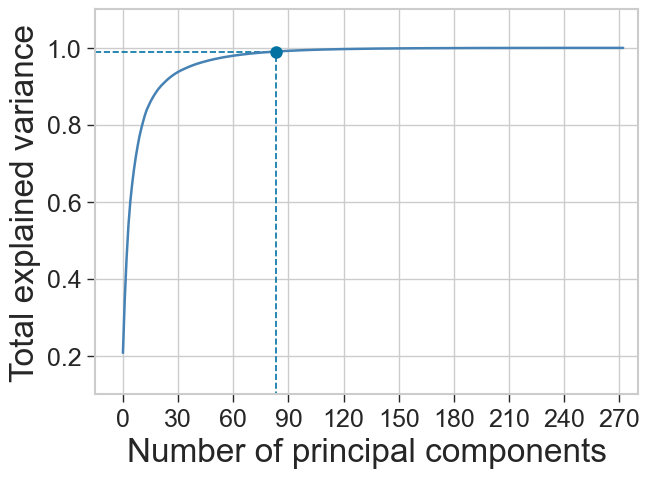

In [14]:
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)

# Plotting
plt.rc('font', family='Arial') 
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.set_xlabel('Number of principal components', fontsize=24, labelpad=4)
ax1.set_ylabel('Total explained variance', fontsize=24, labelpad=4)

ax1.xaxis.set_major_locator(MultipleLocator(30))
# ax1.xaxis.set_minor_locator(MultipleLocator(20))
ax1.tick_params(axis='both', which='major', direction='out', size=6, left='on', bottom='on', width=1, pad=4)
ax1.tick_params(axis='both', which='minor', direction='out', size=6, left='on', bottom='on', width=1, pad=4)
ax1.tick_params(axis="y", labelsize=18)
ax1.tick_params(axis="x", labelsize=18)
# ax1.grid(False)
plt.gcf().set_size_inches((7, 5))
plt.xlim(-15, 280)
plt.ylim(0.1, 1.1)
plt.vlines(83, ymin=0, ymax=0.99, linewidth=1.2, colors='b', linestyles="--")
plt.hlines(0.99, xmin=-15, xmax=83, linewidth=1.2, colors='b', linestyles="--")
evr = np.cumsum(pca.explained_variance_ratio_)

# Plotting the curve
ax1.plot(evr, linestyle='-', linewidth=1.8, color='steelblue')

# Marking the point at x=83 in red
ax1.plot(83, evr[83], marker='.', markersize=18, markeredgecolor='white', color='b', linestyle='-', linewidth=1.5)

plt.tick_params(length=6)
ax = plt.gca()#获取边框
bwith = 1.5 #边框宽度设置
ax.spines['bottom'].set_linewidth(bwith)
ax.spines['left'].set_linewidth(bwith)
ax.spines['top'].set_linewidth(bwith)
ax.spines['right'].set_linewidth(bwith)
#plt.savefig("PCA.svg",bbox_inches = 'tight',dpi=600) 

In [15]:
pca = PCA(random_state=19981024, n_components=83)
X_pca = pca.fit_transform(X_qt)  # Transform feature vectors to PCs
X_pca.shape

(2675, 83)

# 3. Unsupervised learning

## 3.1 Optimization of the number of clusters k for k-means algorithm 

### In the elbow method, the sum of squared errors (SSE) is defined as:
### $SSE=\sum_{i=1}^k\sum_{x\in C_i}\|x-\mu_i\|^2$

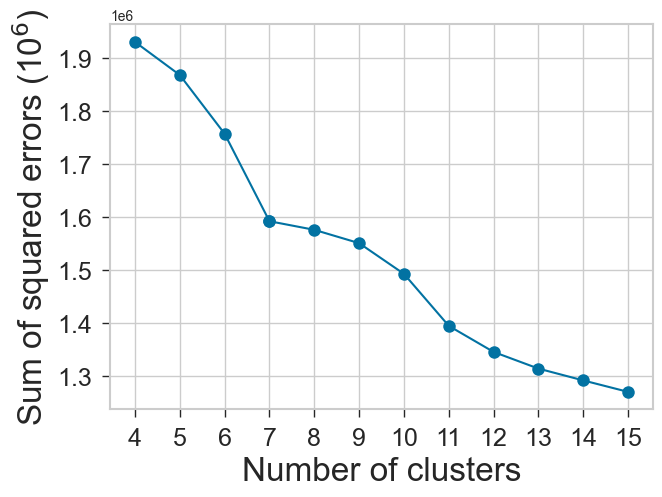

In [16]:
SSE = []  
for k in range(4, 16):
    estimator = KMeans(random_state=1998, n_init="auto", n_clusters=k) 
    estimator.fit(X_pca)
    SSE.append(estimator.inertia_)
X = range(4, 16)

plt.figure(figsize=(7,5))
plt.xlabel('Number of clusters',fontsize=24, labelpad=4)
plt.ylabel('Sum of squared errors (10$^6$)', fontsize=24, labelpad=4)
plt.plot(X, SSE, marker='.', markersize=18, markeredgecolor='white', linestyle='-', linewidth=1.5)

plt.plot(7, SSE[3], marker='.', markersize=18, markeredgecolor='white', color='b')

x = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
plt.xticks(x, fontproperties = 'Arial',size = 18)
plt.yticks(fontproperties = 'Arial',size = 18)

plt.tick_params(length=6)
ax = plt.gca()
bwith = 1.5
ax.spines['bottom'].set_linewidth(bwith)
ax.spines['left'].set_linewidth(bwith)
ax.spines['top'].set_linewidth(bwith)
ax.spines['right'].set_linewidth(bwith)
#plt.savefig("clusters_SSE.svg",bbox_inches = 'tight',dpi=600,transparent=True)
plt.show()

### The silhouette coefficient is defined as:  
### $s(x)=\frac{b(x)-a(x)}{\max(a(x),b(x))}$

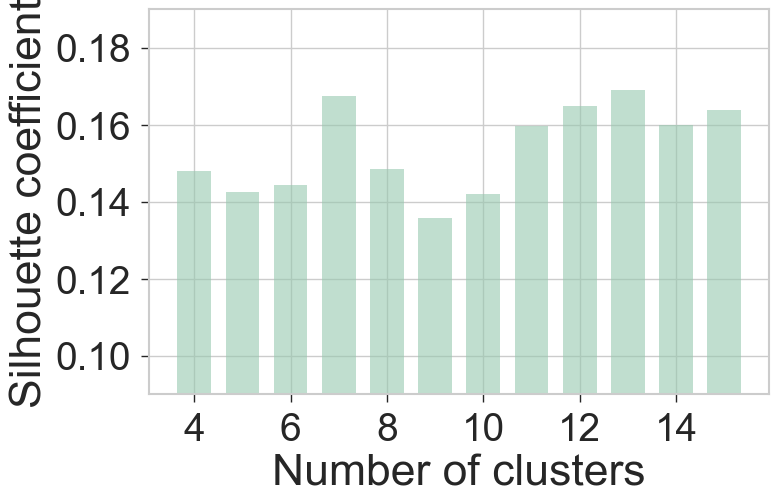

In [19]:
from sklearn.metrics import silhouette_score

plt.figure(figsize=(8,5))
Scores = []  
for k in range(4, 16):
    estimator = KMeans(random_state=1998, n_init="auto", n_clusters=k)  
    estimator.fit(X_pca)
    Scores.append(silhouette_score(X_pca, estimator.labels_, metric='euclidean'))
X_k = range(4, 16)

plt.xlabel('Number of clusters',fontsize=32, labelpad=4)
plt.ylabel('Silhouette coefficient',fontsize=32, labelpad=4)
#plt.plot(X_k, Scores, 'o-')
plt.bar(X_k, Scores, color =['#97C8AF'],linewidth=2,alpha=0.6, width = 0.7)
#plt.bar(X_k, Scores, edgecolor =['#62B197'], color =['#97C8AF'], alpha=0.8,linewidth=2)
plt.xticks(fontproperties = 'Arial',size = 28)
plt.yticks(fontproperties = 'Arial',size = 28)
plt.ylim(0.09, 0.19)

plt.tick_params(length=6)
ax = plt.gca()
bwith = 1.5 
ax.spines['bottom'].set_linewidth(bwith)
ax.spines['left'].set_linewidth(bwith)
ax.spines['top'].set_linewidth(bwith)
ax.spines['right'].set_linewidth(bwith)
#plt.savefig("clusters_SC.svg",bbox_inches = 'tight',dpi=600,transparent=True)
plt.show()

### Obviously, we choose k = 7 as the optimal cluster

In [20]:
model = KMeans(random_state=1998, n_init="auto", n_clusters=7)
model.fit(X_pca)

KMeans(n_clusters=7, n_init='auto', random_state=1998)

In [24]:
predictions = model.predict(X_pca)

# calculating the Counts of the cluster
unique, counts = np.unique(predictions, return_counts=True)
counts = counts.reshape(1,7)

# Creating a datagrame
countscldf = pd.DataFrame(counts, columns = ["Cluster 0","Cluster 1","Cluster 2", "Cluster 3", "Cluster 4",
                                            "Cluster 5","Cluster 6"])
# display
countscldf

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
0,219,485,436,219,508,318,490


In [25]:
df_ = df_fea.copy()
df_['label'] = pd.DataFrame(predictions)
df_.head()

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,compound possible,max ionic char,avg ionic char,label
0,6,3,LiBeSb,ABC,102.232248,4.473698,mp-9575,-3.567269,-0.308157,0.017807,...,21.777778,166.0,0.277778,0.166667,0.555556,0.000000,True,0.248906,0.043136,3
1,4,2,K3Sb,AB3,151.112621,2.626915,mp-10159,-11.473373,-0.533096,0.015186,...,23.625000,229.0,0.277778,0.166667,0.555556,0.000000,True,0.314924,0.059048,3
2,8,3,Na2CuP,ABC2,154.577587,3.018608,mp-7639,-7.208147,-0.463838,0.000000,...,84.625000,229.0,0.277778,0.166667,0.555556,0.000000,False,0.327599,0.068451,1
3,14,3,Ba3OsN3,AB3C3,332.309469,6.438402,mp-1029640,-6.639529,-0.639654,0.000000,...,17.142857,194.0,0.325581,0.209302,0.139535,0.325581,False,0.685139,0.157102,0
4,6,2,As2Os,AB2,102.413553,11.027932,mp-2455,-27.770656,-0.303893,0.000000,...,12.444444,166.0,0.115385,0.115385,0.500000,0.269231,False,0.000100,0.000022,0


## 3.2 Use t-SNE visualization for the seven clusters 

In [21]:
tsne = TSNE(n_components=2, random_state=1998) #, perplexity=32)#, init='pca')
X_tsne = tsne.fit_transform(X_pca)
X_tsne.shape

(2675, 2)

In [22]:
X_tsne = pd.DataFrame(X_tsne)
X_tsne

,0,1
0,60.704742,-9.493186
1,59.611042,2.343218
2,47.946667,7.809127
3,-23.179012,-2.362708
4,-17.973833,-7.784041
...,...,...
2670,-40.580181,29.437649
2671,30.294491,-54.465382
2672,-10.817012,23.075186
2673,14.366343,27.449385


In [26]:
X_tsne['label'] = pd.DataFrame(predictions)
X_tsne['material_id'] = df['material_id']
X_tsne['formula_pretty'] = df['formula_pretty']
X_tsne

,0,1,label,material_id,formula_pretty
0,60.704742,-9.493186,3,mp-9575,LiBeSb
1,59.611042,2.343218,3,mp-10159,K3Sb
2,47.946667,7.809127,1,mp-7639,Na2CuP
3,-23.179012,-2.362708,0,mp-1029640,Ba3OsN3
4,-17.973833,-7.784041,0,mp-2455,As2Os
...,...,...,...,...,...
2670,-40.580181,29.437649,6,mp-1215424,ZnGeP2
2671,30.294491,-54.465382,4,mp-566257,Li4Mo3O8
2672,-10.817012,23.075186,0,mp-1217291,TePb2Se
2673,14.366343,27.449385,5,mp-1223443,KBiS2


In [27]:
X_0 = X_tsne[X_tsne['label']==0]
X_0

,0,1,label,material_id,formula_pretty
3,-23.179012,-2.362708,0,mp-1029640,Ba3OsN3
4,-17.973833,-7.784041,0,mp-2455,As2Os
15,-14.868115,7.097516,0,mp-20098,Ba2PbO4
22,-17.726589,8.694248,0,mp-29208,Ca(MgBi)2
34,-25.813501,-4.921450,0,mp-5513,Tl3VS4
...,...,...,...,...,...
2620,-15.719706,-2.348446,0,mp-559122,WO3
2638,-11.927016,14.147932,0,mp-1216612,TlIn5S8
2645,-15.576251,-1.912914,0,mp-636148,WO3
2648,-22.332157,-9.251988,0,mp-1095507,SbIrSe


In [28]:
X_1 = X_tsne[X_tsne['label']==1]
X_1

,0,1,label,material_id,formula_pretty
2,47.946667,7.809127,1,mp-7639,Na2CuP
7,41.747375,2.635290,1,mp-10667,SrAgP
13,22.391657,-2.604577,1,mp-11694,Cs2Pd3Se4
16,30.758780,19.529772,1,mp-23231,AgBr
23,54.167694,21.969723,1,mp-9872,K4BeP2
...,...,...,...,...,...
2630,1.967894,-0.992199,1,mp-861245,LiAgF4
2643,36.060200,12.638391,1,mp-556225,Ag2S
2649,13.508160,7.360382,1,mp-1227860,BaPPd
2656,25.075560,-6.090362,1,mp-9797,K(SbSe2)2


In [29]:
X_2 = X_tsne[X_tsne['label']==2]
X_2

,0,1,label,material_id,formula_pretty
18,-23.979658,-42.239883,2,mp-5986,BaTiO3
35,-37.409100,-26.468401,2,mp-226,FeS2
39,-40.244587,-11.215881,2,mp-1014244,ZrZnN2
43,-33.895142,-25.735071,2,mp-4627,CoAsS
45,-37.417740,-26.465366,2,mp-1522,FeS2
...,...,...,...,...,...
2659,-50.235313,-7.707914,2,mp-759662,V2O3F
2660,-28.167297,-39.946365,2,mp-1287570,CaMn2O4
2662,-44.044216,-10.318244,2,mp-1079726,Zr2SeN2
2665,-50.877781,-6.953641,2,mp-755290,V3(O2F)2


In [30]:
X_3 = X_tsne[X_tsne['label']==3]
X_3

,0,1,label,material_id,formula_pretty
0,60.704742,-9.493186,3,mp-9575,LiBeSb
1,59.611042,2.343218,3,mp-10159,K3Sb
8,56.499046,-12.238747,3,mp-8603,RbAgO
11,43.247368,-18.777262,3,mp-22660,InAgO2
12,53.785126,-13.049737,3,mp-8187,K2ZnO2
...,...,...,...,...,...
2624,56.869576,-11.883814,3,mp-1103169,NaAgO
2641,62.177341,-9.525393,3,mp-1222280,LiInSn
2642,60.532299,-9.630784,3,mp-7756,SrLiSb
2655,50.480915,-20.097038,3,mp-754468,NaCuO2


In [31]:
X_4 = X_tsne[X_tsne['label']==4]
X_4

,0,1,label,material_id,formula_pretty
5,25.176964,-36.290661,4,mp-961682,TiSnPd
14,14.909014,-29.724686,4,mp-5621,NbCu3S4
19,10.711397,-33.112442,4,mp-1029422,NbZn2N3
21,9.807320,-26.387590,4,mp-33363,LiYS2
25,16.963341,-27.962259,4,mp-2030,RuS2
...,...,...,...,...,...
2658,35.722519,-47.038582,4,mp-14100,Cd(RhO2)2
2664,-0.274601,-44.392139,4,mp-754266,Li8TiS6
2667,1.395772,-17.850180,4,mp-1205928,K3RuF6
2671,30.294491,-54.465382,4,mp-566257,Li4Mo3O8


In [32]:
X_5 = X_tsne[X_tsne['label']==5]
X_5

,0,1,label,material_id,formula_pretty
9,19.890461,45.912731,5,mp-1019105,KMgBi
27,15.604513,53.042488,5,mp-20343,NaAuO2
28,8.454959,33.599854,5,mp-13992,Cs2Pt3S4
37,16.448006,51.211666,5,mp-8176,RbTlO2
38,13.152493,54.904850,5,mp-29396,Cu2PbO2
...,...,...,...,...,...
2632,15.648790,53.127426,5,mp-997089,NaAuO2
2635,9.880830,26.626474,5,mp-1095499,CsAuCl4
2650,15.628389,31.762548,5,mp-570238,P10Au7I
2653,19.754122,30.322794,5,mp-27916,AgBiSe2


In [33]:
X_6 = X_tsne[X_tsne['label']==6]
X_6

,0,1,label,material_id,formula_pretty
6,-46.452091,31.175369,6,mp-9569,Ca(ZnP)2
10,-22.619509,37.167870,6,mp-1958,SrTe
17,-46.446686,31.289810,6,mp-8276,Sr(ZnP)2
20,-35.301361,54.101002,6,mp-1009733,Ca2Si
29,-39.526424,12.342949,6,mp-7770,Sr(ZnAs)2
...,...,...,...,...,...
2639,-29.250031,16.440088,6,mp-12866,SrSnO3
2654,-44.317200,27.083811,6,mp-12181,BaSnS2
2661,-32.721565,24.513201,6,mp-22189,In6TeO12
2669,-39.282192,27.391815,6,mp-644431,Cd2P3Cl


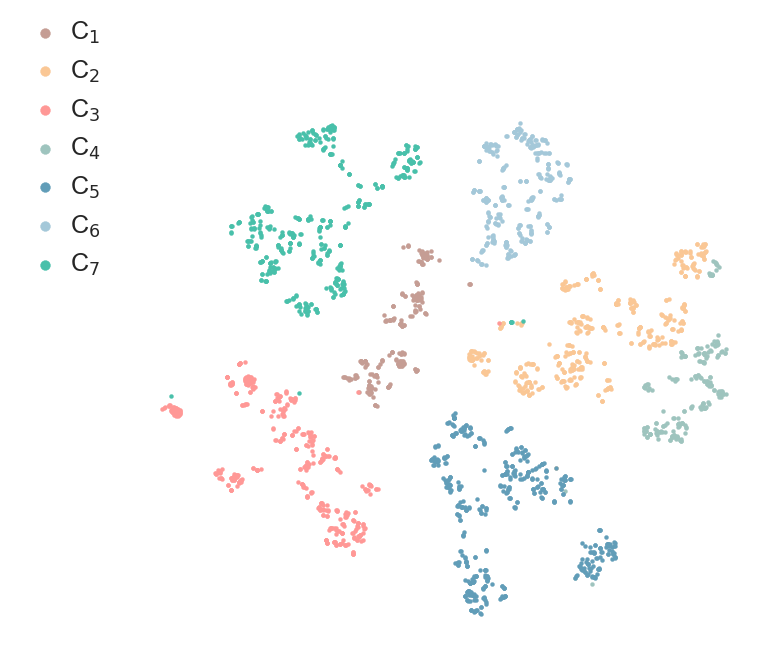

In [34]:
plt.figure(figsize=(8,7))

plt.scatter(X_0.iloc[:, 0], X_0.iloc[:, 1], color='#C59D94', s=8, label="C$_{1}$") 
plt.scatter(X_1.iloc[:, 0], X_1.iloc[:, 1], color="#FAC795", s=8, label="C$_{2}$") 
plt.scatter(X_2.iloc[:, 0], X_2.iloc[:, 1], color="#FF9896", s=8, label="C$_{3}$") 
plt.scatter(X_3.iloc[:, 0], X_3.iloc[:, 1], color="#9EC4BE", s=8, label="C$_{4}$") 
plt.scatter(X_4.iloc[:, 0], X_4.iloc[:, 1], color="#619DB8", s=8, label="C$_{5}$") 
plt.scatter(X_5.iloc[:, 0], X_5.iloc[:, 1], color="#A4C8D9", s=8, label="C$_{6}$") 
plt.scatter(X_6.iloc[:, 0], X_6.iloc[:, 1], color="#48C0AA", s=8, label="C$_{7}$") 

plt.axis('off')
plt.legend(bbox_to_anchor=(-0.2, 0.65), loc=3, borderaxespad=0,frameon=False,
          prop={'family':'Arial', 'size':18}, handletextpad=0, markerscale=2.5)

#plt.savefig("t-sne-visualization.svg",bbox_inches = 'tight',dpi=600)
plt.show()

### The reported $\kappa_\mathrm{L}$ values at 300 K for several known materials included in each cluster are collected from the previous studies  
### The known materials with relatively low $\kappa_\mathrm{L}$ are clustered into $C_{1}$ and $C_{2}$

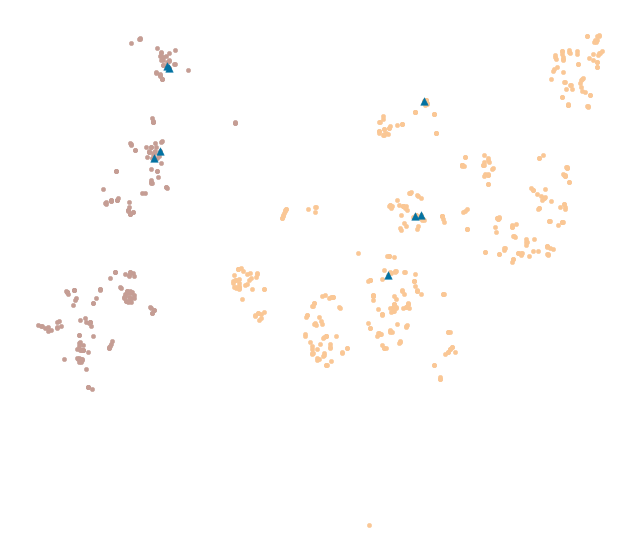

In [35]:
plt.figure(figsize=(8,7))

plt.scatter(X_0.iloc[:, 0], X_0.iloc[:, 1], color='#C59D94', s=10, label="Cluster 0") 
plt.scatter(X_1.iloc[:, 0], X_1.iloc[:, 1], color="#FAC795", s=10, label="Cluster 1") 

X0_highlight_indices = [1020, 1061, 1520, 1684]
X0_highlight_points = X_0.loc[X0_highlight_indices]
plt.scatter(X0_highlight_points.iloc[:, 0], X0_highlight_points.iloc[:, 1],marker='^', color='b', s=30) #edgecolors='white',linewidth=0.2

X1_highlight_indices = [99, 325, 687, 1819]
X1_highlight_points = X_1.loc[X1_highlight_indices]
plt.scatter(X1_highlight_points.iloc[:, 0], X1_highlight_points.iloc[:, 1],marker='^', color='b', s=30)
plt.axis('off')
#plt.savefig("t-sne-cluster_0_1.svg",bbox_inches = 'tight',dpi=600,transparent=True)
plt.show()

# 4. Merge cluster $C_{1}$ and $C_{2}$

In [36]:
df_0 = df_[df_['label']==0]
df_0.reset_index(drop=True, inplace=True)
df_0.shape

(219, 290)

In [37]:
df_1 = df_[df_['label']==1]
df_1.reset_index(drop=True, inplace=True)
df_1.shape

(485, 290)

In [38]:
df_01 = pd.concat([df_0, df_1], axis=0)
df_01.reset_index(drop=True, inplace=True)
df_01

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,compound possible,max ionic char,avg ionic char,label
0,14,3,Ba3OsN3,AB3C3,332.309469,6.438402,mp-1029640,-6.639529,-0.639654,0.00000,...,17.142857,194.0,0.325581,0.209302,0.139535,0.325581,False,0.685139,0.157102,0
1,6,2,As2Os,AB2,102.413553,11.027932,mp-2455,-27.770656,-0.303893,0.00000,...,12.444444,166.0,0.115385,0.115385,0.500000,0.269231,False,0.000100,0.000022,0
2,7,3,Ba2PbO4,AB2C4,125.836511,7.203060,mp-20098,-6.275103,-2.366581,0.00000,...,105.632653,12.0,0.250000,0.321429,0.178571,0.250000,True,0.803211,0.169289,0
3,5,3,Ca(MgBi)2,AB2C2,151.723980,5.545004,mp-29208,-3.125956,-0.536452,0.00000,...,92.320000,12.0,0.156250,0.093750,0.312500,0.437500,False,0.229026,0.039166,0
4,8,3,Tl3VS4,AB3C4,218.276540,6.027814,mp-5513,-4.949173,-0.855203,0.00000,...,66.375000,70.0,0.145455,0.172727,0.300000,0.381818,True,0.205784,0.051210,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,6,3,LiAgF4,ABC4,72.338285,4.379915,mp-861245,-7.908514,-1.868980,0.01043,...,94.222222,15.0,0.250000,0.500000,0.250000,0.000000,False,0.894601,0.177264,1
700,6,2,Ag2S,AB2,122.885288,6.697041,mp-556225,-17.033617,-0.118033,0.00000,...,68.888889,225.0,0.142857,0.142857,0.714286,0.000000,True,0.100238,0.022275,1
701,12,3,BaPPd,ABC,306.177431,5.959741,mp-1227860,-5.120960,-0.949516,0.00000,...,100.000000,2.0,0.235294,0.176471,0.588235,0.000000,False,0.348856,0.077053,1
702,14,3,K(SbSe2)2,AB2C4,429.799846,4.624308,mp-9797,-16.956796,-0.574348,0.00000,...,84.734694,14.0,0.136842,0.231579,0.631579,0.000000,False,0.526794,0.065749,1


In [39]:
df_f = df_01.drop(['structure'], axis=1)

In [40]:
df_f.to_json('./data/MP_dataset_cluster_0_1.json')